In [9]:
!pip install -q xgboost imbalanced-learn shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [10]:
DATA_PATH = "/kaggle/input/datasets/bytechainers/advanced-synthetic-crm-churn-50000/advanced_synthetic_crm_churn_50000.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head(3))
print("\nChurn rate:", df["churn_30d"].mean().round(4))

Shape: (50000, 27)
   customer_id snapshot_date  customer_age_days acquisition_channel plan_type  \
0            1    2026-03-02               1855             Organic   Premium   
1            2    2026-03-02                345              Direct   Premium   
2            3    2026-03-02                 51            Referral   Premium   

   days_since_last_purchase  purchases_last_30d  purchases_last_90d  \
0                       131                   0                   3   
1                        87                   2                   2   
2                       144                   2                   3   

   purchases_last_180d  total_spend_last_30d  ...  tickets_last_30d  \
0                    6                  0.00  ...                 1   
1                    6                510.73  ...                 1   
2                    5                891.91  ...                 0   

   tickets_last_90d  avg_resolution_time  payment_failures_last_90d  \
0              

In [11]:
TARGET = "churn_30d"

X = df.drop(columns=["customer_id", "snapshot_date", TARGET])
y = df[TARGET].astype(int)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), "Test churn rate:", y_test.mean().round(4))

Train: (40000, 24) Test: (10000, 24)
Train churn rate: 0.431 Test churn rate: 0.431


In [12]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

In [18]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

baseline_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    min_child_weight=1,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", baseline_model)
])

baseline_pipe.fit(X_train, y_train)
probs = baseline_pipe.predict_proba(X_test)[:, 1]

print("Baseline ROC-AUC:", roc_auc_score(y_test, probs).round(4))
print("Baseline PR-AUC :", average_precision_score(y_test, probs).round(4))

Baseline ROC-AUC: 0.7217
Baseline PR-AUC : 0.6658


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__n_estimators": [300, 500, 700, 900],
    "model__subsample": [0.6, 0.75, 0.85, 1.0],
    "model__colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "model__min_child_weight": [1, 2, 4, 6],
    "model__gamma": [0, 0.5, 1, 2],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

tune_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tune_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", tune_model)
])

search = RandomizedSearchCV(
    estimator=tune_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best Params:", search.best_params_)
best_pipe = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC: 0.7215
Best Params: {'model__subsample': 0.6, 'model__reg_lambda': 5.0, 'model__n_estimators': 900, 'model__min_child_weight': 6, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 1, 'model__colsample_bytree': 1.0}


In [23]:
best_params

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 1.0,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 1,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.01,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': 6,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 900,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': 5.0,
 'sampling_method': None,
 'scale_pos_weight': np.float64(1.320185614849188),
 'subsample': 0.6,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [36]:
# Transform data using the preprocessing part only
prep_only = best_pipe.named_steps["prep"]
Xtr = prep_only.fit_transform(X_train)
Xte = prep_only.transform(X_test)

# Create a validation split from training data for early stopping
Xtr_train, Xtr_val, ytr_train, ytr_val = train_test_split(
    Xtr, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

for k, v in best_pipe.get_params().items():
    if k.startswith("model__"):
        best_params[k.replace("model__", "")] = v

final_model = xgb.XGBClassifier(
    n_estimators=best_params.get("n_estimators"),
    max_depth=best_params.get("max_depth"),
    learning_rate=best_params.get("learning_rate"),
    subsample=best_params.get("subsample"),
    colsample_bytree=best_params.get("colsample_bytree"),
    reg_lambda=best_params.get("reg_lambda"),
    min_child_weight=best_params.get("min_child_weight"),
    gamma=best_params.get("gamma"),
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50
)

final_model.fit(
    Xtr_train, ytr_train,
    eval_set=[(Xtr_val, ytr_val)],
    verbose=False,
)

test_probs = final_model.predict_proba(Xte)[:, 1]
print("Final ROC-AUC:", roc_auc_score(y_test, test_probs).round(4))
print("Final PR-AUC :", average_precision_score(y_test, test_probs).round(4))

Final ROC-AUC: 0.7252
Final PR-AUC : 0.6692


In [37]:
prec, rec, thr = precision_recall_curve(y_test, test_probs)
f1 = (2 * prec * rec) / (prec + rec + 1e-9)

best_f1_idx = np.argmax(f1)
best_thr_f1 = thr[best_f1_idx] if best_f1_idx < len(thr) else 0.5

# Example: choose a threshold that achieves at least 0.80 recall (if possible)
target_recall = 0.80
idx_recall = np.where(rec >= target_recall)[0]
best_thr_recall = thr[idx_recall[-1]] if len(idx_recall) > 0 and idx_recall[-1] < len(thr) else best_thr_f1

print("Best threshold (max F1):", round(float(best_thr_f1), 4))
print("Threshold for recall >= 0.80:", round(float(best_thr_recall), 4))

Best threshold (max F1): 0.3529
Threshold for recall >= 0.80: 0.4124


Chosen threshold: 0.3529

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.37      0.51      5690
           1       0.52      0.88      0.65      4310

    accuracy                           0.59     10000
   macro avg       0.66      0.63      0.58     10000
weighted avg       0.68      0.59      0.57     10000



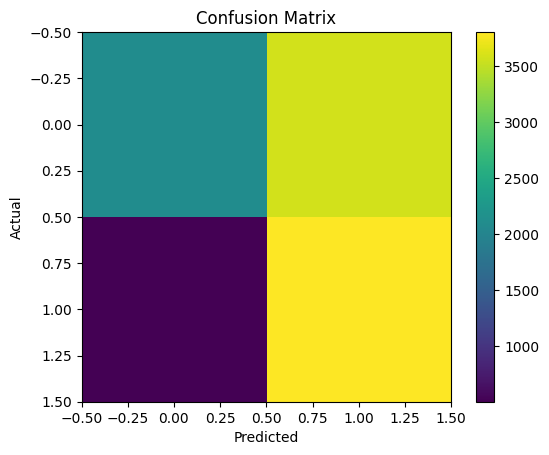

In [38]:
chosen_threshold = best_thr_f1  # change to best_thr_recall if you want high recall
preds = (test_probs >= chosen_threshold).astype(int)

print("Chosen threshold:", round(float(chosen_threshold), 4))
print("\nClassification Report:\n", classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

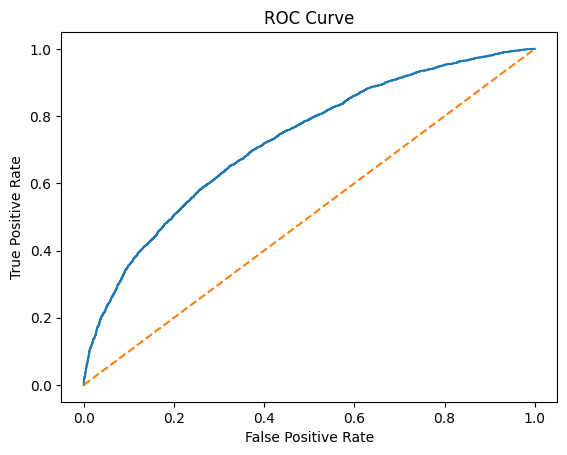

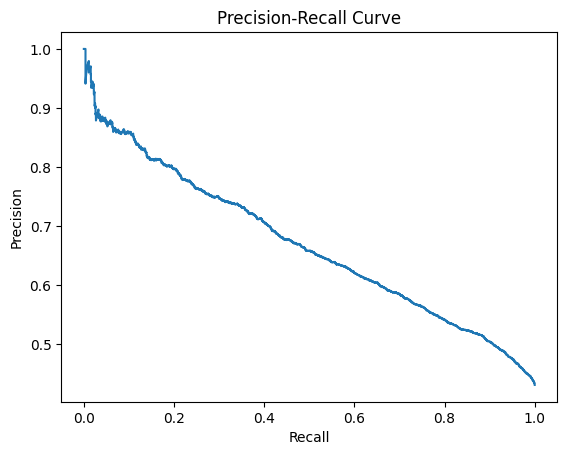

ROC-AUC: 0.7252
PR-AUC : 0.6692


In [39]:
# ROC
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# PR
plt.figure()
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, test_probs).round(4))
print("PR-AUC :", average_precision_score(y_test, test_probs).round(4))

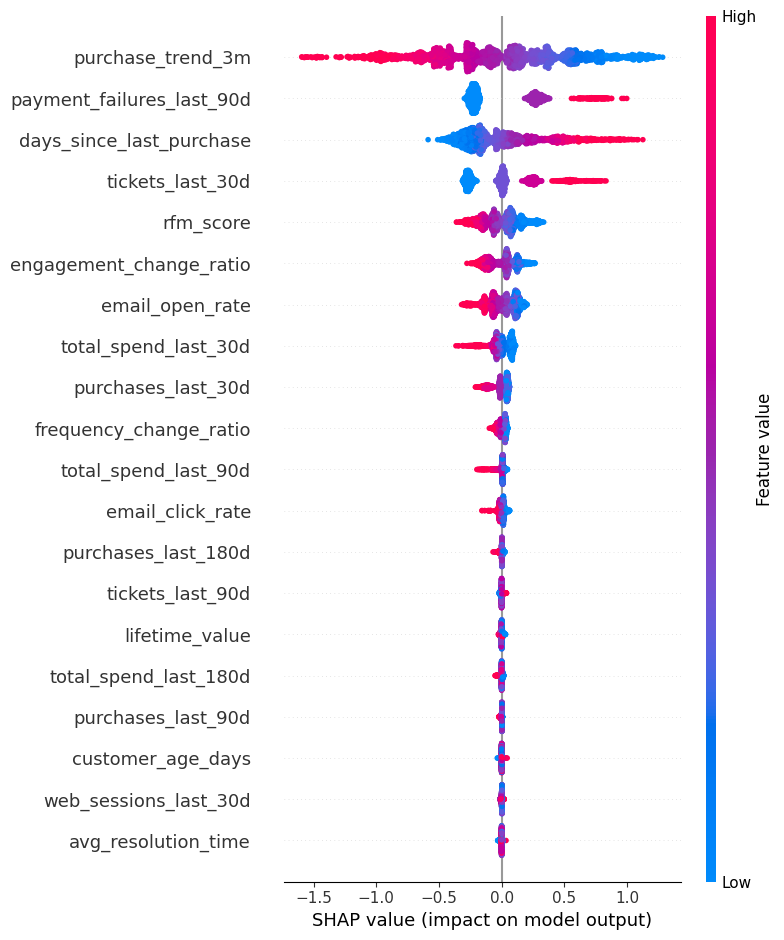

In [40]:
# SHAP expects dense arrays sometimes; we sample for speed
sample_size = 2000
idx = np.random.choice(len(Xte), size=min(sample_size, len(Xte)), replace=False)
X_sample = Xte[idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

# feature names after one-hot encoding
ohe = prep_only.named_transformers_["cat"]
ohe_feature_names = list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) > 0 else []
feature_names = ohe_feature_names + num_cols

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=True)

In [41]:
joblib.dump(prep_only, "prep_transformer.pkl")
joblib.dump(final_model, "advanced_xgb_churn_model.pkl")

print("Saved:")
print("- prep_transformer.pkl")
print("- advanced_xgb_churn_model.pkl")

Saved:
- prep_transformer.pkl
- advanced_xgb_churn_model.pkl


In [42]:
import numpy as np
import pandas as pd

TARGET = "churn_30d"

df_fe = df.copy()

# ---- Trend flags / non-linear transforms (from SHAP insights) ----
df_fe["decline_flag"] = (df_fe["purchase_trend_3m"] < -0.5).astype(int)
df_fe["sharp_decline_flag"] = (df_fe["purchase_trend_3m"] < -1.0).astype(int)
df_fe["trend_abs"] = df_fe["purchase_trend_3m"].abs()
df_fe["trend_sq"] = df_fe["purchase_trend_3m"] ** 2

# ---- Key interactions (SHAP indicated strong drivers) ----
df_fe["recency_x_paymentfail"] = df_fe["days_since_last_purchase"] * df_fe["payment_failures_last_90d"]
df_fe["recency_x_tickets"] = df_fe["days_since_last_purchase"] * df_fe["tickets_last_30d"]
df_fe["fail_x_lowengage"] = df_fe["payment_failures_last_90d"] * (df_fe["email_open_rate"] < 0.2).astype(int)

# Optional: clamp extreme interaction values (stabilizes training)
df_fe["recency_x_paymentfail"] = np.clip(df_fe["recency_x_paymentfail"], 0, df_fe["recency_x_paymentfail"].quantile(0.99))
df_fe["recency_x_tickets"] = np.clip(df_fe["recency_x_tickets"], 0, df_fe["recency_x_tickets"].quantile(0.99))

print("✅ Feature engineering done. New shape:", df_fe.shape)
df_fe.head(2)

✅ Feature engineering done. New shape: (50000, 34)


,customer_id,snapshot_date,customer_age_days,acquisition_channel,plan_type,days_since_last_purchase,purchases_last_30d,purchases_last_90d,purchases_last_180d,total_spend_last_30d,...,frequency_change_ratio,rfm_score,churn_30d,decline_flag,sharp_decline_flag,trend_abs,trend_sq,recency_x_paymentfail,recency_x_tickets,fail_x_lowengage
0,1,2026-03-02,1855,Organic,Premium,131,0,3,6,0.00,...,0.00,0.1193,0,0,0,1.26,1.5876,131,131,0
1,2,2026-03-02,345,Direct,Premium,87,2,2,6,510.73,...,0.67,0.0706,0,0,0,0.40,0.1600,0,87,0


In [43]:
# Drop low-signal/noise features found near the bottom of SHAP plot
DROP_COLS = [
    "avg_resolution_time",
    "web_sessions_last_30d",
    "customer_age_days"
]

# Only drop if present
DROP_COLS = [c for c in DROP_COLS if c in df_fe.columns]
df_fe = df_fe.drop(columns=DROP_COLS)

print("✅ Dropped low-importance features:", DROP_COLS)
print("New shape:", df_fe.shape)

✅ Dropped low-importance features: ['avg_resolution_time', 'web_sessions_last_30d', 'customer_age_days']
New shape: (50000, 31)


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = df_fe.drop(columns=["customer_id", "snapshot_date", TARGET])
y = df_fe[TARGET].astype(int)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("scale_pos_weight:", round(scale_pos_weight, 3))

Train: (40000, 28) Test: (10000, 28)
scale_pos_weight: 1.32


In [45]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base = xgb.XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", xgb_base)
])

param_dist = {
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__n_estimators": [400, 700, 1000],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 2, 4, 6],
    "model__gamma": [0, 0.5, 1.5, 3],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("✅ Best CV ROC-AUC:", round(search.best_score_, 4))
print("✅ Best Params:", search.best_params_)
best_pipe = search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
✅ Best CV ROC-AUC: 0.7208
✅ Best Params: {'model__subsample': 0.85, 'model__reg_lambda': 2.0, 'model__n_estimators': 700, 'model__min_child_weight': 6, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__gamma': 3, 'model__colsample_bytree': 0.7}


In [46]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

# Extract preprocessing and params
prep_only = best_pipe.named_steps["prep"]
Xtr = prep_only.fit_transform(X_train)
Xte = prep_only.transform(X_test)

Xtr_train, Xtr_val, ytr_train, ytr_val = train_test_split(
    Xtr, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# Pull tuned model params
best_params = {}
for k, v in best_pipe.get_params().items():
    if k.startswith("model__"):
        best_params[k.replace("model__", "")] = v

# Ensure n_estimators is large enough for early stopping to be meaningful
best_params["n_estimators"] = max(int(best_params.get("n_estimators", 700)), 800)

final_model = xgb.XGBClassifier(
    n_estimators=best_params.get("n_estimators"),
    max_depth=best_params.get("max_depth"),
    learning_rate=best_params.get("learning_rate"),
    subsample=best_params.get("subsample"),
    colsample_bytree=best_params.get("colsample_bytree"),
    reg_lambda=best_params.get("reg_lambda"),
    min_child_weight=best_params.get("min_child_weight"),
    gamma=best_params.get("gamma"),
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50
)

final_model.fit(
    Xtr_train, ytr_train,
    eval_set=[(Xtr_val, ytr_val)],
    verbose=False
)

test_probs = final_model.predict_proba(Xte)[:, 1]
print("✅ Final ROC-AUC:", round(roc_auc_score(y_test, test_probs), 4))
print("✅ Final PR-AUC :", round(average_precision_score(y_test, test_probs), 4))
print("Best iteration:", getattr(final_model, "best_iteration", None))

✅ Final ROC-AUC: 0.7249
✅ Final PR-AUC : 0.6694
Best iteration: 725


In [47]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

prec, rec, thr = precision_recall_curve(y_test, test_probs)

f1 = (2 * prec * rec) / (prec + rec + 1e-9)
best_f1_idx = np.argmax(f1)
best_thr_f1 = thr[best_f1_idx] if best_f1_idx < len(thr) else 0.5

target_recall = 0.80
idx = np.where(rec >= target_recall)[0]
best_thr_recall = thr[idx[-1]] if len(idx) > 0 and idx[-1] < len(thr) else best_thr_f1

print("✅ Best threshold (max F1):", round(float(best_thr_f1), 4))
print("✅ Threshold for recall>=0.80:", round(float(best_thr_recall), 4))

# Choose one:
chosen_threshold = best_thr_f1   # or best_thr_recall

preds = (test_probs >= chosen_threshold).astype(int)
print("\nChosen threshold:", round(float(chosen_threshold), 4))
print("\nClassification Report:\n", classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)

✅ Best threshold (max F1): 0.3515
✅ Threshold for recall>=0.80: 0.4035

Chosen threshold: 0.3515

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.38      0.51      5690
           1       0.52      0.87      0.65      4310

    accuracy                           0.59     10000
   macro avg       0.66      0.63      0.58     10000
weighted avg       0.68      0.59      0.57     10000

Confusion Matrix:
 [[2163 3527]
 [ 550 3760]]


In [49]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

calib_model = xgb.XGBClassifier(
    n_estimators=best_params.get("n_estimators"),
    max_depth=best_params.get("max_depth"),
    learning_rate=best_params.get("learning_rate"),
    subsample=best_params.get("subsample"),
    colsample_bytree=best_params.get("colsample_bytree"),
    reg_lambda=best_params.get("reg_lambda"),
    min_child_weight=best_params.get("min_child_weight"),
    gamma=best_params.get("gamma"),
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Calibrate on the TRAIN portion only (use transformed arrays)
calibrator = CalibratedClassifierCV(calib_model, method="isotonic", cv=3)
calibrator.fit(Xtr, y_train)

cal_probs = calibrator.predict_proba(Xte)[:, 1]

print("✅ Calibrated ROC-AUC:", round(roc_auc_score(y_test, cal_probs), 4))
print("✅ Calibrated PR-AUC :", round(average_precision_score(y_test, cal_probs), 4))
print("✅ Brier (uncal):", round(brier_score_loss(y_test, test_probs), 4))
print("✅ Brier (cal)  :", round(brier_score_loss(y_test, cal_probs), 4))

✅ Calibrated ROC-AUC: 0.7247
✅ Calibrated PR-AUC : 0.6682
✅ Brier (uncal): 0.2112
✅ Brier (cal)  : 0.2076


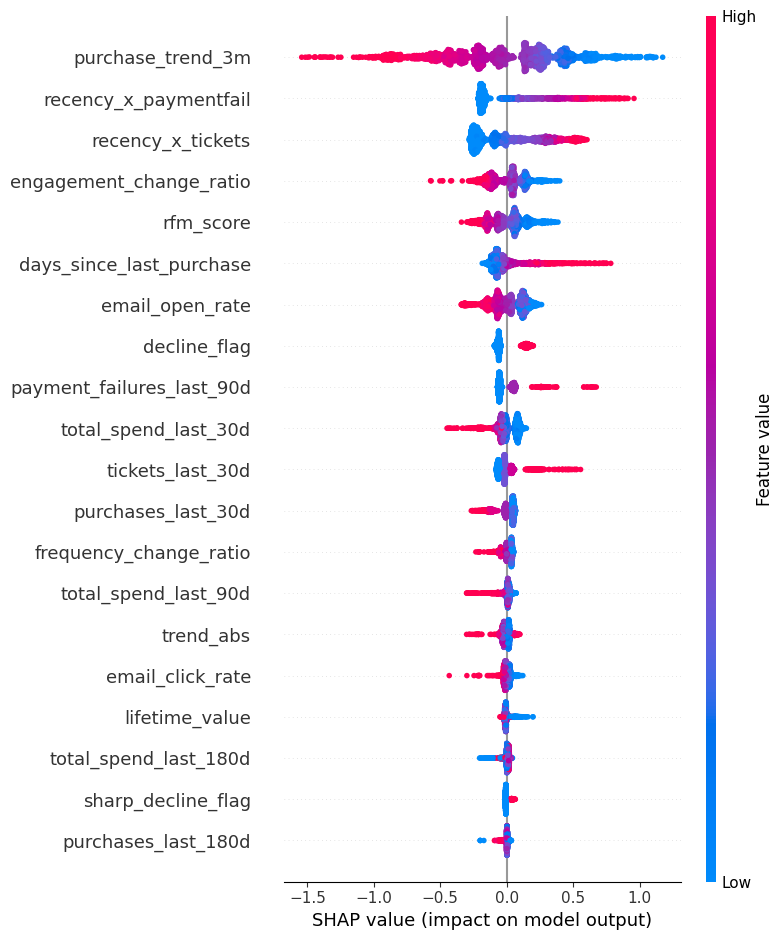

In [50]:
import shap

# Sample for speed
sample_size = 2000
idx = np.random.choice(Xte.shape[0], size=min(sample_size, Xte.shape[0]), replace=False)
X_sample = Xte[idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

# get one-hot feature names
ohe = prep_only.named_transformers_["cat"]
ohe_feature_names = list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) > 0 else []
feature_names = ohe_feature_names + num_cols

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=True)

In [51]:
import joblib

joblib.dump(prep_only, "prep_transformer_v2.pkl")
joblib.dump(final_model, "xgb_churn_model_v2.pkl")
# If you used calibration:
# joblib.dump(calibrator, "xgb_churn_calibrator_v2.pkl")

print("✅ Saved: prep_transformer_v2.pkl, xgb_churn_model_v2.pkl")

✅ Saved: prep_transformer_v2.pkl, xgb_churn_model_v2.pkl


In [52]:
joblib.dump(calibrator, "xgb_churn_calibrator_v2.pkl")

['xgb_churn_calibrator_v2.pkl']